In [2]:

# Ethiopian E-commerce Data Analysis

## 1. Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/ethiopian_products_150k.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (150000, 21)


,product_id,name,name_amharic,description,description_amharic,category,subcategory,price,currency,brand,...,delivery_available,rating,stock_status,stock_quantity,weight_kg,dimensions,warranty_months,seller_name,seller_rating,tags
0,ETP00001,ethio coffee beverages premium,ኢትዮ ቡና Beverages ከፍተኛ ጥራት,Ethio Coffee Beverages with premium features. ...,ንጹህ እና ጥራት ያለው ኢትዮጵያዊ ምርት።,Food & Beverages,Beverages,1300,ETB,Ethio Coffee,...,Yes,4.2,In Stock,860,0.42,13x29x15 cm,3,Ethio Coffee Market,4.0,"Food & Beverages,Beverages,Addis Ababa,Ethio C..."
1,ETP00002,"asus 50"" uhd tv",Asus ቴሌቪዥን ባህላዊ,Asus Televisions with premium features. Believ...,ረጅም ጊዜ ለመጠቀም የሚረቁ።,Electronics,Televisions,68500,ETB,Asus,...,Yes,3.6,In Stock,161,21.75,134x64x11 cm,12,Asus Gadget Center,3.7,"Electronics,Televisions,Gondar,asus,Ethiopian-..."
2,ETP00003,auto addis tools deluxe,Auto Addis Tools,AUTO ADDIS LATEST TOOLS MODEL. BREAK ESPECIALL...,ከፍተኛ ጥራት ያለው ምርት። ለእረፍት ይሆናል,Automotive,Tools,12500,ETB,Auto Addis,...,Yes,4.1,In Stock,465,1.09,41x11x18 cm,0,Auto Addis Supplier,4.3,"Automotive,Tools,Bahir Dar,Auto Addis,Ethiopia..."
3,ETP00004,ETHIO SPORTS FITNESS PROFESSIONAL,Ethio Sports Fitness,Ethio Sports Fitness with premium features. Ba...,ከፍተኛ ጥራት ያለው ምርት። ለእረፍት ይሆናል,Sports,Fitness,5900,ETB,Ethio Sports,...,Yes,4.3,In Stock,378,1.17,33x13x18 cm,0,Ethio Sports Shop,4.3,"Sports,Fitness,Asosa,Ethio Sports,Ethiopian-made"
4,ETP00005,tomoca herbal tea 250g,ቶሞካ ሻይ ዘመናዊ,tomoca tea with premium features. word street ...,ከአካባቢ አርሶ አደሮች የተሰበሰበ።,Food & Beverages,Tea,1900,ETB,Tomoca,...,Yes,3.8,In Stock,407,0.77,12x13x6 cm,6,Tomoca Distributor,3.9,"Food & Beverages,Tea,Mekelle,Tomoca,Ethiopian-..."


In [3]:
print("Basic Statistics:")
print(f"Total products: {len(df)}")
print(f"Categories: {df['category'].nunique()}")
print(f"Price range: ${df['price'].min()} - ${df['price'].max()}")
print(f"Average rating: {df['rating'].mean():.2f}")

Basic Statistics:
Total products: 150000
Categories: 10
Price range: $50 - $180000
Average rating: 3.68


In [4]:
def calculate_delivery_availability(df):
    # Count how many products have delivery available
    total_products = len(df)
    available = (df['delivery_available'] == 'Yes').sum()
    percent_available = (available / total_products) * 100

    print(f"✅ Delivery available for {available}/{total_products} products")
    print(f"📊 Delivery Availability: {percent_available:.2f}%")
    return percent_available

# Example usage
calculate_delivery_availability(df)

✅ Delivery available for 115278/150000 products
📊 Delivery Availability: 76.85%


76.852

In [6]:
def print_category_counts(df):
    counts = df['category'].value_counts()
    for category in [
        'Food & Beverages', 'Fashion', 'Beauty & Personal Care', 'Electronics',
        'Home & Kitchen', 'Books & Stationery', 'Health', 'Sports',
        'Baby & Kids', 'Automotive'
    ]:
        count = counts.get(category, 0)
        print(f"• {category}: {count}")

# Example usage
print_category_counts(df)

• Food & Beverages: 6846
• Fashion: 44171
• Beauty & Personal Care: 19168
• Electronics: 13266
• Home & Kitchen: 2539
• Books & Stationery: 2485
• Health: 887
• Sports: 29470
• Baby & Kids: 13371
• Automotive: 17797


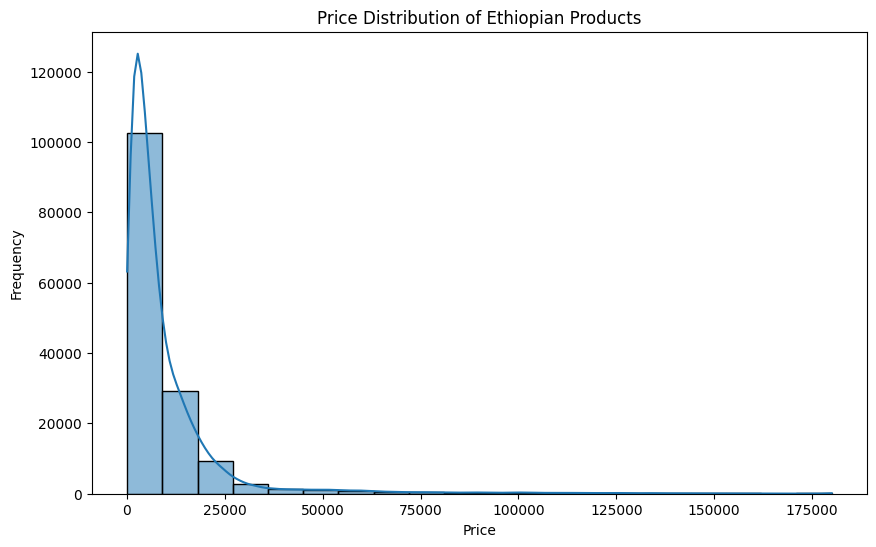

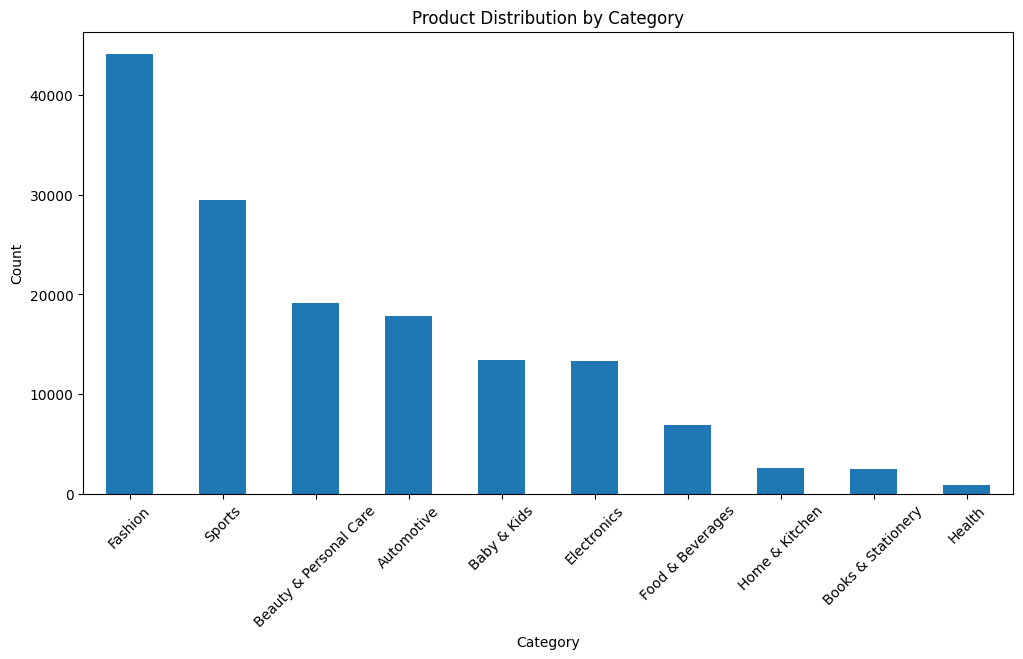

In [3]:
# Price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=20, kde=True)
plt.title('Price Distribution of Ethiopian Products')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Category distribution
plt.figure(figsize=(12, 6))
df['category'].value_counts().plot(kind='bar')
plt.title('Product Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Products with Amharic descriptions: 150000


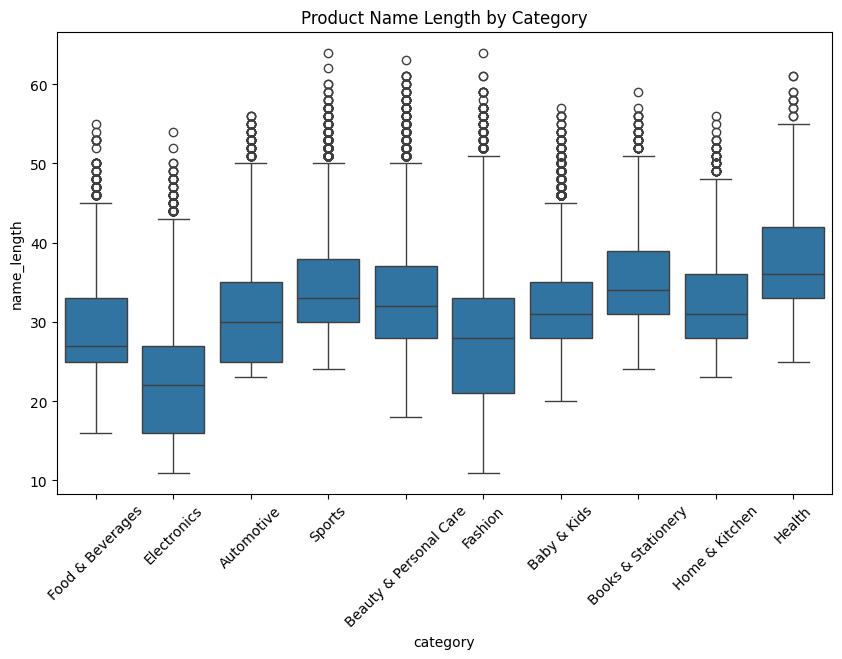

In [5]:
# Check Amharic content
amharic_products = df[df['description_amharic'].notna()]
print(f"Products with Amharic descriptions: {len(amharic_products)}")

# Character distribution
df['name_length'] = df['name'].apply(len)
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='name_length', data=df)
plt.title('Product Name Length by Category')
plt.xticks(rotation=45)
plt.show()

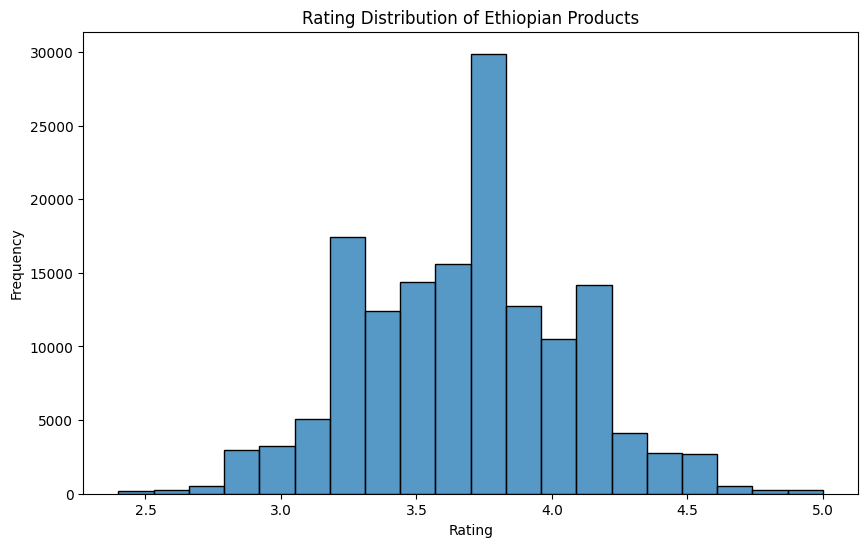

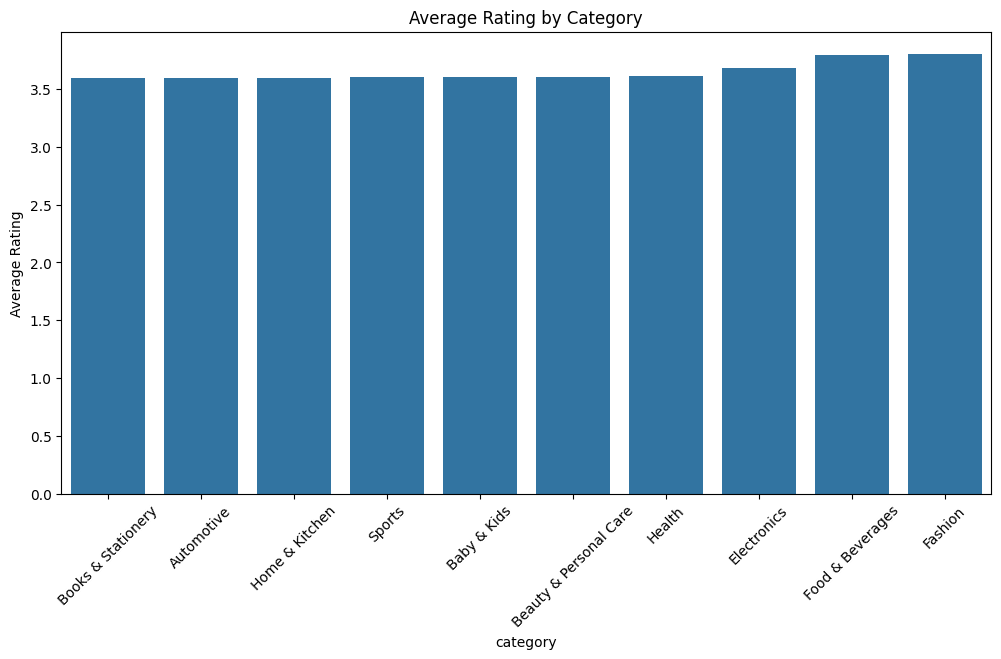

In [6]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=20, kde=False)
plt.title('Rating Distribution of Ethiopian Products')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Average rating per category
plt.figure(figsize=(12, 6))
avg_rating_per_cat = df.groupby('category')['rating'].mean().sort_values()
sns.barplot(x=avg_rating_per_cat.index, y=avg_rating_per_cat.values)
plt.title('Average Rating by Category')
plt.xticks(rotation=45)
plt.ylabel('Average Rating')
plt.show()


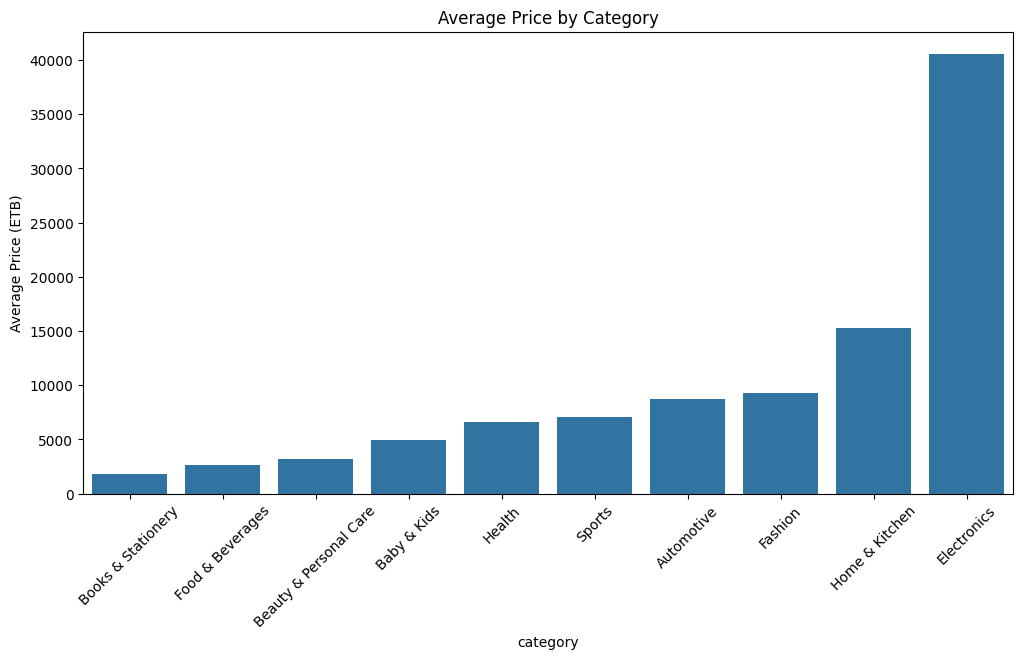

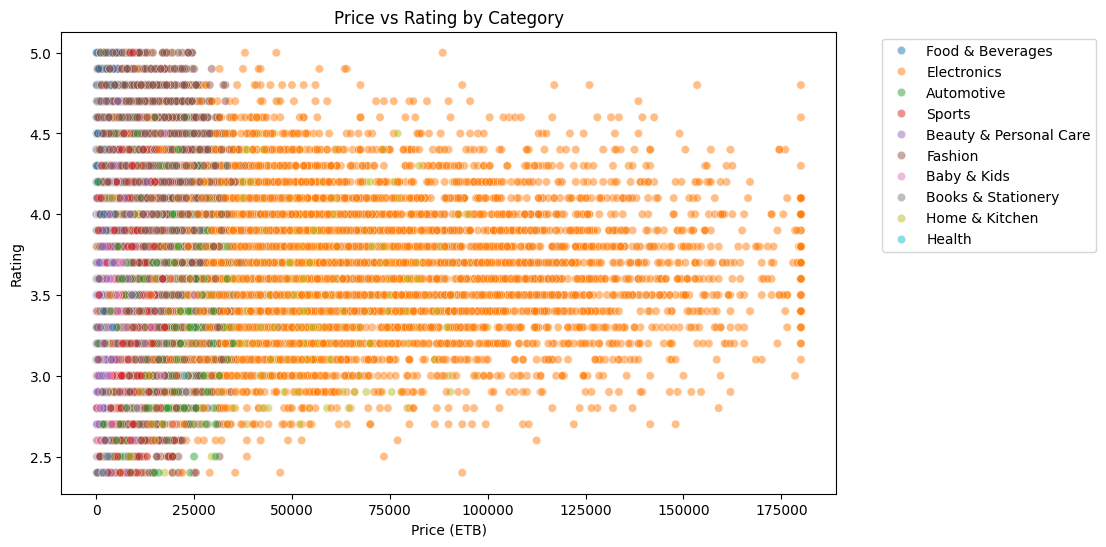

In [7]:
# Average price per category
plt.figure(figsize=(12, 6))
avg_price_per_cat = df.groupby('category')['price'].mean().sort_values()
sns.barplot(x=avg_price_per_cat.index, y=avg_price_per_cat.values)
plt.title('Average Price by Category')
plt.xticks(rotation=45)
plt.ylabel('Average Price (ETB)')
plt.show()

# Price vs Rating scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='rating', hue='category', data=df, alpha=0.5)
plt.title('Price vs Rating by Category')
plt.xlabel('Price (ETB)')
plt.ylabel('Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


<Figure size 1200x600 with 0 Axes>

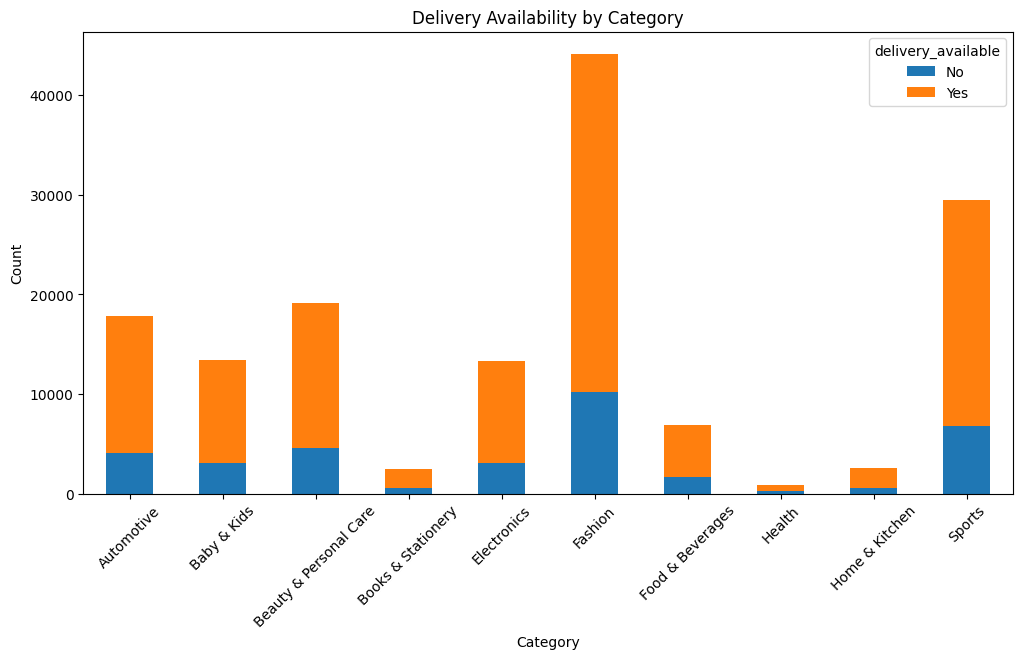

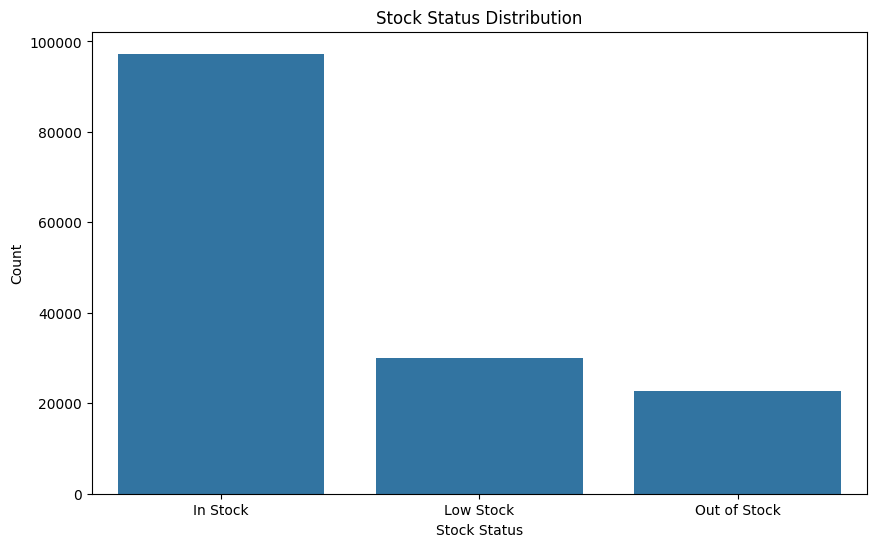

In [8]:
# Delivery availability by category
plt.figure(figsize=(12, 6))
delivery_counts = df.groupby(['category', 'delivery_available']).size().unstack(fill_value=0)
delivery_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Delivery Availability by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Stock status distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='stock_status', data=df, order=df['stock_status'].value_counts().index)
plt.title('Stock Status Distribution')
plt.xlabel('Stock Status')
plt.ylabel('Count')
plt.show()


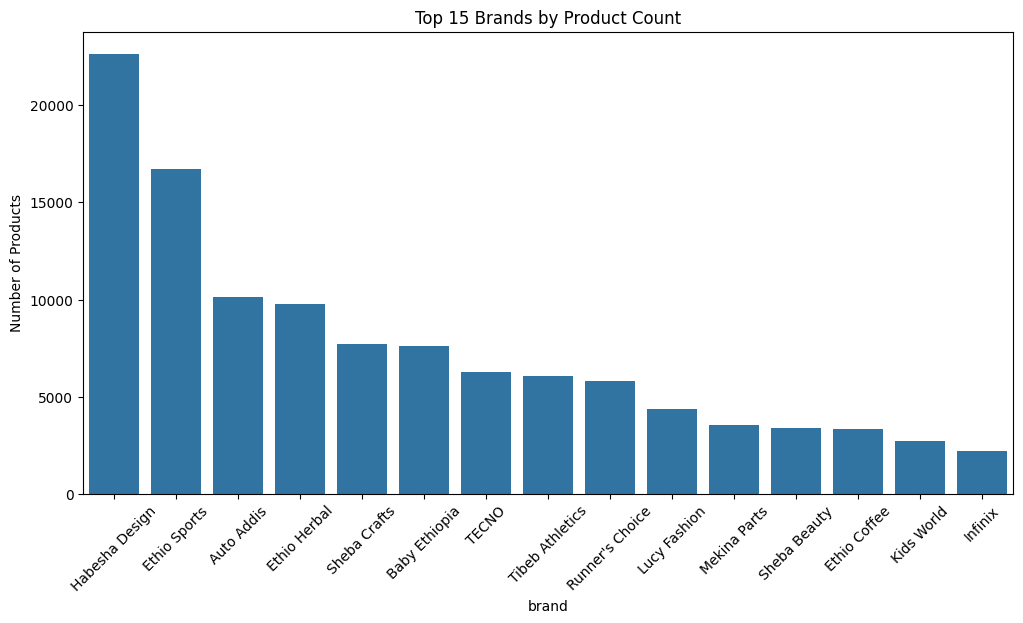

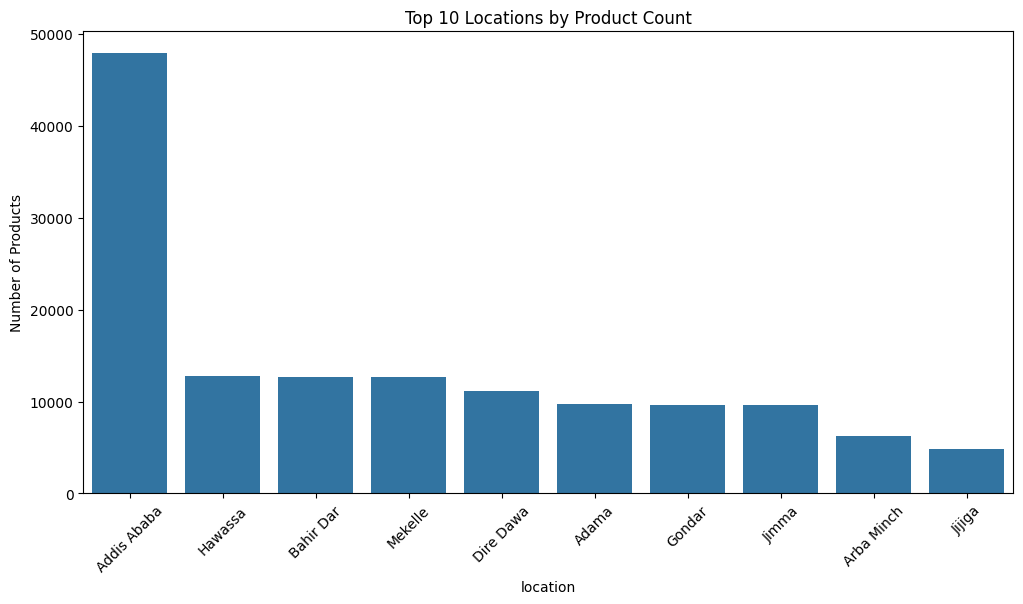

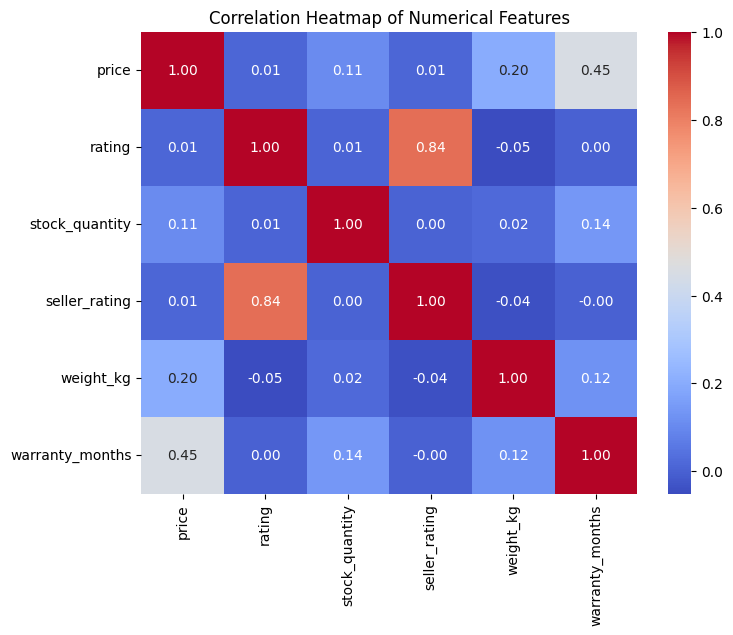

In [9]:
# Top 15 brands
plt.figure(figsize=(12, 6))
top_brands = df['brand'].value_counts().head(15)
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title('Top 15 Brands by Product Count')
plt.xticks(rotation=45)
plt.ylabel('Number of Products')
plt.show()

# Location distribution (top 10)
plt.figure(figsize=(12, 6))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.index, y=top_locations.values)
plt.title('Top 10 Locations by Product Count')
plt.xticks(rotation=45)
plt.ylabel('Number of Products')
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df[['price', 'rating', 'stock_quantity', 'seller_rating', 'weight_kg', 'warranty_months']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()